# v2.3 Test Weighting


## Environment Setup

In [1]:
import numpy as np
import sys
sys.path.append('..')
import pickle
import logging
import os.path as osp
import tensorflow as tf
from moisture_rnn_pkl import pkl2train
from moisture_rnn import RNNParams, RNNData, RNN, rnn_data_wrap
from utils import hash2, read_yml, read_pkl, retrieve_url, Dict, print_dict_summary, print_first, str2time, logging_setup
from moisture_rnn import RNN
import reproducibility
from data_funcs import rmse, to_json, combine_nested, subset_by_features, read_and_clean
from moisture_models import run_augmented_kf
from metrics import ros_3wind
import copy
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import time

In [2]:
logging_setup()

In [3]:
filename = "fmda_rocky_202403-05_f05.pkl"
retrieve_url(
    url = f"https://demo.openwfm.org/web/data/fmda/dicts/{filename}", 
    dest_path = f"../data/{filename}")

Target data already exists at ../data/fmda_rocky_202403-05_f05.pkl


In [4]:
file_paths = [f'../data/{filename}']

In [5]:
# # read/write control
# train_file='../data/train.pkl'
# train_create=True   # if false, read
# train_write=False
# train_read=False

In [6]:
# Params used for data filtering
params_data = read_yml("../params_data.yaml") 
params_data

{'max_intp_time': 10,
 'zero_lag_threshold': 10,
 'hours': 720,
 'min_fm': 1,
 'max_fm': 90,
 'min_rain': 0,
 'max_rain': 100,
 'min_wind': 0,
 'max_wind': 35,
 'min_solar': 0,
 'max_solar': 1400,
 'min_soilm': 0}

In [7]:
# Params used for setting up RNN
params = read_yml("../params.yaml", subkey='rnn') 

In [8]:
feats = ['Ed', 'Ew', 'solar', 'wind', 'elev', 'lon', 'lat', 'rain']
params.update({'features_list': feats})

In [9]:
train = read_and_clean(file_paths, atm_source="HRRR", params_data = params_data, verbose=True)
train = combine_nested(train)

Shifting time based on forecast step 3. Dropping NA at beginning of feature data and corresponding times of output data
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Extracting data from input file ../data/fmda_rocky_202403-05_f05.pkl
loading file ../data/fmda_rocky_202403-05_f05.pkl
2024-11-21 16:59:48,311 - INFO - CPTC2_202403 HRRR.time time array increments are 1.0 hours
2024-11-21 16:59:48,322 - INFO - CPTC2 RAWS.time_raws time array increments are min 1.0 max 2.0
2024-11-21 16:59:48,359 - INFO - CHAC2_202403 HRRR.time time array increments are 1.0 hours
2024-11-21 16:59:48,369 - INFO - CHAC2 RAWS.time_raws time array increments are 1.0 hours
2024-11-21 16:59:48,405 - INFO - CHRC2_202403 HRRR.time time array increments are 1.0 hours
2024-11-21 16:59:48,415 - INFO - CHRC2 RAWS.time_raws time array increments are min 1.0 max 3.0
2024-11-21 16:59:48,451 - INFO - DYKC2_202403 HRRR.time time array increments are 1.0 hours
2024-11-21 16:59:48,461 - INFO - DY

In [10]:
# if train_create:
#     params_data.update({'hours': 1440})
#     logging.info('creating the training cases from files %s',file_paths)
#     # osp.join works on windows too, joins paths using \ or /
#     train = process_train_dict(file_paths, atm_dict = "RAWS", params_data = params_data, verbose=True)
#     train = subset_by_features(train, feats)
#     train = combine_nested(train)
# if train_write:
#     with open(train_file, 'wb') as file:
#         logging.info('Writing the rain cases into file %s',train_file)
#         pickle.dump(train, file)
# if train_read:
#     logging.info('Reading the train cases from file %s',train_file)
#     train = read_pkl(train_file)

## Train Models

In [11]:
reproducibility.set_seed(123)

resetting random seeds to 123


In [12]:
params = RNNParams(params)

params.update({
    'hidden_layers': ['dense', 'lstm', 'conv1d', 'dense'],
    'hidden_units': [64, 32, 32, 16],
    'hidden_activation': ['relu','tanh', 'relu', 'relu'],
    'batch_schedule_type': None,
    'stateful': False,
    'early_stopping_patience':15
})

Checking params...
Input dictionary passed all checks.
Calculating shape params based on features list, timesteps, and batch size
Input Feature List: ['Ed', 'Ew', 'solar', 'wind', 'elev', 'lon', 'lat', 'rain']
Input Timesteps: 12
Input Batch Size: 32
Calculated params:
Number of features: 8
Batch Shape: (32, 12, 8)
{'timesteps': 12, 'batch_size': 32, 'hidden_layers': ['lstm', 'dense', 'dropout'], 'hidden_units': [32, 16, None], 'hidden_activation': ['tanh', 'relu', None], 'dropout': 0.2, 'recurrent_dropout': 0.2, 'output_layer': 'dense', 'output_activation': 'linear', 'output_dimension': 1, 'learning_rate': 0.0002, 'early_stopping_patience': 5, 'epochs': 100, 'reset_states': True, 'bmin': 10, 'bmax': 200, 'batch_schedule_type': 'step', 'estep': 5, 'features_list': ['Ed', 'Ew', 'solar', 'wind', 'elev', 'lon', 'lat', 'rain'], 'scaler': 'standard', 'time_fracs': [0.8, 0.1, 0.1], 'space_fracs': [0.8, 0.1, 0.1], 'stateful': True, 'verbose_fit': True, 'verbose_weights': True, 'return_sequenc

In [13]:
import importlib
import moisture_rnn
importlib.reload(moisture_rnn)
from moisture_rnn import RNNData

In [14]:
rnn_dat_sp = rnn_data_wrap(train, params)

Input data from multiple timeseries.
Setting data scaler: standard
Setting features_list to ['Ed', 'Ew', 'solar', 'wind', 'elev', 'lon', 'lat', 'rain']. 
  NOTE: not subsetting features yet. That happens in train_test_split.
Subsetting input data to features_list: ['Ed', 'Ew', 'solar', 'wind', 'elev', 'lon', 'lat', 'rain']
Train index: 0 to 573
Validation index: 573 to 645
Test index: 645 to 717
Subsetting locations into train/val/test
Total Locations: 273
Train Locations: 218
Val. Locations: 27
Test Locations: 28
X_train[0] shape: (573, 8), y_train[0] shape: (573, 1)
X_val[0] shape: (72, 8), y_val[0] shape: (72, 1)
X_test[0] shape: (72, 8), y_test[0] shape: (72, 1)
Scaling training data with scaler StandardScaler(), fitting on X_train
Reshaping spatial training data using batch size: 32 and timesteps: 12
Setting total hours to minimum length of y in provided dictionary
Reshaping validation data using batch size: 32 and timesteps: 12
Setting total hours to minimum length of y in provid

resetting random seeds to 123
Initial Weights Hash: 3bfc68d541a1373cbad83e86f8462a02
Hash of X: 8b22cb16ca81062b864f48eb8a0fca4b
Hash of y: 3de49fb305f38f97b66274f42b76f810
Hash of X_train: 620503d236e1ef236a9714be397eaaf8
Hash of y_train: de1033e1259601df5ae0f64e4c122935
Hash of X_val: 8df7c332747b617193666d1b5ed14145
Hash of y_val: 4c78cb3cf2ae6d795e0bc6e063cb1466
Hash of X_test: cfd716d2bda7b05b0d8b4407960024b9
Hash of y_test: 34a7b231379c13132d390241410e4f10
Running Spatial Training Set
Training simple RNN with params: {'timesteps': 12, 'batch_size': 32, 'hidden_layers': ['dense', 'lstm', 'conv1d', 'dense'], 'hidden_units': [64, 32, 32, 16], 'hidden_activation': ['relu', 'tanh', 'relu', 'relu'], 'dropout': 0.2, 'recurrent_dropout': 0.2, 'output_layer': 'dense', 'output_activation': 'linear', 'output_dimension': 1, 'learning_rate': 0.0002, 'early_stopping_patience': 15, 'epochs': 100, 'reset_states': True, 'bmin': 10, 'bmax': 200, 'batch_schedule_type': None, 'estep': 5, 'features_l

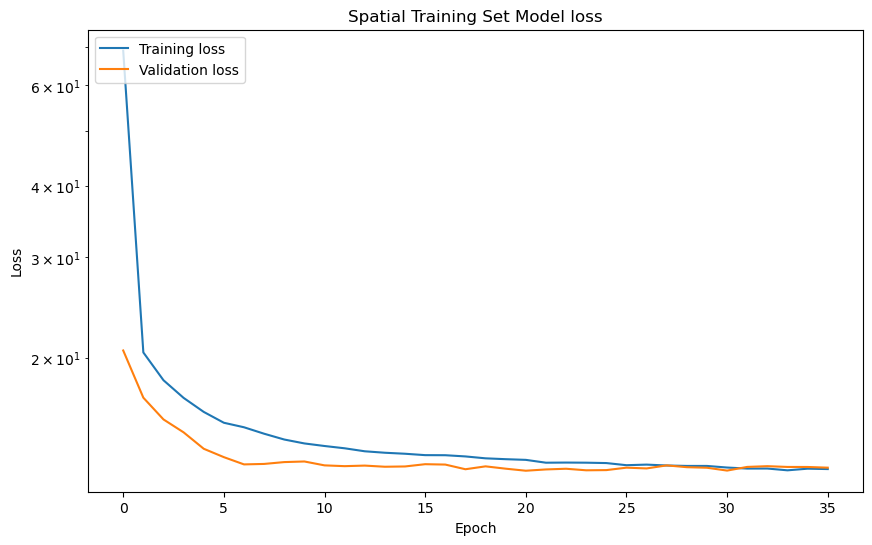

Fitted Weights Hash: 8e8da931ae2675776b8423b19c74d647
Predicting test data
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
errs0.mean()=3.810098683549032


In [15]:
reproducibility.set_seed(123)
rnn0 = RNN(params)
m0, errs0 = rnn0.run_model(rnn_dat_sp)
print(f"{errs0.mean()=}")

### Custom Loss

In [16]:
params.update({
    'w_alpha': 0.0367 
})

resetting random seeds to 123
Initial Weights Hash: 3bfc68d541a1373cbad83e86f8462a02
Hash of X: 8b22cb16ca81062b864f48eb8a0fca4b
Hash of y: 3de49fb305f38f97b66274f42b76f810
Hash of X_train: 620503d236e1ef236a9714be397eaaf8
Hash of y_train: de1033e1259601df5ae0f64e4c122935
Hash of X_val: 8df7c332747b617193666d1b5ed14145
Hash of y_val: 4c78cb3cf2ae6d795e0bc6e063cb1466
Hash of X_test: cfd716d2bda7b05b0d8b4407960024b9
Hash of y_test: 34a7b231379c13132d390241410e4f10
Running Spatial Training Set
Training simple RNN with params: {'timesteps': 12, 'batch_size': 32, 'hidden_layers': ['dense', 'lstm', 'conv1d', 'dense'], 'hidden_units': [64, 32, 32, 16], 'hidden_activation': ['relu', 'tanh', 'relu', 'relu'], 'dropout': 0.2, 'recurrent_dropout': 0.2, 'output_layer': 'dense', 'output_activation': 'linear', 'output_dimension': 1, 'learning_rate': 0.0002, 'early_stopping_patience': 15, 'epochs': 100, 'reset_states': True, 'bmin': 10, 'bmax': 200, 'batch_schedule_type': None, 'estep': 5, 'features_l

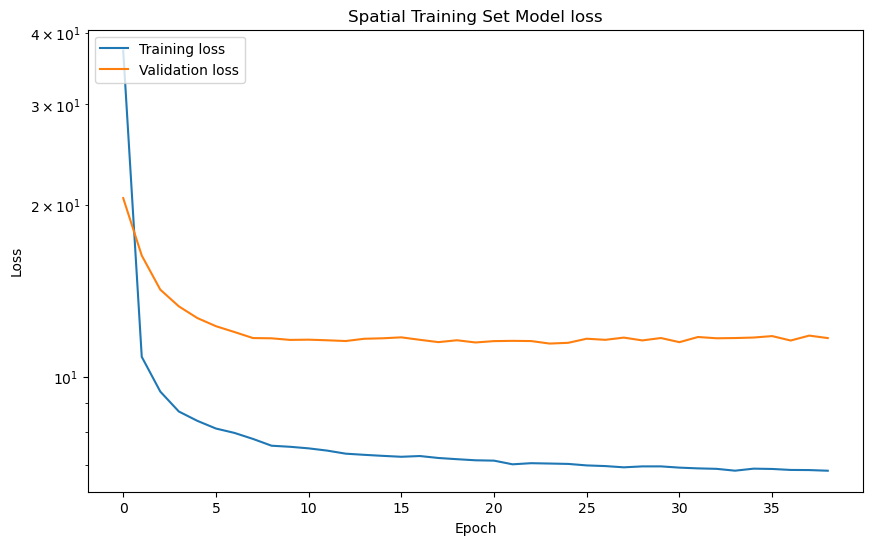

Fitted Weights Hash: d62db277f674c6a6ed18548c90a9afe9
Predicting test data
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
errs1.mean()=3.732287874661867


In [17]:
reproducibility.set_seed(123)
rnn1 = RNN(params)
m1, errs1 = rnn1.run_model(rnn_dat_sp)
print(f"{errs1.mean()=}")

## Compare ROS

In [18]:
ros_truth = ros_3wind(rnn_dat_sp.y_test)
ros0 = ros_3wind(m0)
ros1 = ros_3wind(m1)

In [19]:
from utils import rmse_3d

In [20]:
ros_truth.shape

(28, 72, 1)

In [21]:
ros1.shape

(28, 72, 1)

In [22]:
rmse_3d(ros_truth, ros0).mean()

0.006745274710466094

In [23]:
rmse_3d(ros_truth, ros1).mean()

0.006516789742137256

In [24]:
np.all(ros_truth[0,:,0] == ros_3wind(rnn_dat_sp.y_test[0,:,0]))

True

In [25]:
# Pairwise Percent Diff (relative to standard MSE baseline)
((rmse_3d(ros_truth, ros0)- rmse_3d(ros_truth, ros1))/rmse_3d(ros_truth, ros0)).mean()

0.048975331071482275

In [26]:
## Confirm element-wise division below
# ((rmse_3d(ros_truth, ros0)- rmse_3d(ros_truth, ros1))/rmse_3d(ros_truth, ros0))
# (rmse_3d(ros_truth, ros0)- rmse_3d(ros_truth, ros1))[0] / rmse_3d(ros_truth, ros0)[0]